# Etna Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Etna dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend; only lagged `tau >= 1` parents are fed into the Cause–Trigger F-test, while contemporaneous `tau = 0` links are stored as diagnostics.

## 1. Imports and paths
This section loads the local modules from `src/` and sets data paths.  

In [1]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "etna"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from etna_cause_trigger import (
    EtnaWorkflowConfig,
    load_model_frame,
    model_overview,
    target_extremes,
    split_diagnostics,
    select_lag_by_var,
    run_suite,
    run_sensitivity_grid,
    plot_effect_with_split,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

In [2]:
ETNA_PATH = DATA_DIR / "etna_final.csv"
EFFECT = "effect_seismic_scaled"
EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

X = load_model_frame(ETNA_PATH)

display(pd.DataFrame([model_overview(X, EFFECT)]))
display(X.head())
display(target_extremes(X, EFFECT, n=10))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,816,9,2008-04-12 00:00:00+00:00,2008-05-15 23:00:00+00:00,h,effect_seismic_scaled,-0.522346,-0.522334,-9.143013e-17,5.204879,0.812934,0.000033,816


,teleseismic_scaled,background_seismic_scaled,effect_seismic_scaled,CO2_3_scaled,AirTemp_3_scaled,pressure_drop_scaled,WindSpeed_scaled,API_scaled,CO2_SO2_scaled
time,,,,,,,,,
2008-04-12 00:00:00+00:00,-0.524396,-0.439008,-0.522339,-1.608241,0.245730,-0.165741,-0.706846,-0.790848,1.274923
2008-04-12 01:00:00+00:00,-0.524441,-0.438997,-0.522336,-1.977481,1.644570,0.315624,-0.557935,-0.790848,1.274923
2008-04-12 02:00:00+00:00,-0.524413,-0.439018,-0.522340,-1.631206,0.624639,0.822623,-0.706846,-0.790848,1.274923
2008-04-12 03:00:00+00:00,-0.524466,-0.439001,-0.522340,-1.792526,0.723780,0.535398,-0.706846,-0.790848,1.274923
2008-04-12 04:00:00+00:00,-0.524394,-0.439033,-0.522338,-1.815574,0.476607,-0.054617,-0.706846,-0.790848,1.274923


,effect_seismic_scaled,abs_effect
time,,
2008-04-18 02:00:00+00:00,5.204879,5.204879
2008-05-13 12:00:00+00:00,4.290368,4.290368
2008-04-22 09:00:00+00:00,3.450736,3.450736
2008-04-21 20:00:00+00:00,3.120315,3.120315
2008-05-04 00:00:00+00:00,3.117145,3.117145
2008-04-22 08:00:00+00:00,2.746844,2.746844
2008-04-25 01:00:00+00:00,2.746511,2.746511
2008-04-29 04:00:00+00:00,2.742869,2.742869
2008-05-13 21:00:00+00:00,2.328709,2.328709


## 2. Main configuration and split check

Before any causal discovery, we check whether the split is scientifically sensible. 
For Etna, the detected split should be close to the known teleseismic/eruption episode if the chosen interval and effect are appropriate.


In [3]:
workflow = EtnaWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    manual_lag=3,
    max_lags=6,
    min_I1_length=48,
    min_I2_length=48,
    distribution="gaussian",
)

split_row = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([split_row]))

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,distance_to_event,boundary_split
0,effect_seismic_scaled,661,2008-05-09 13:00:00+00:00,661,155,0.041549,0.177186,0.135637,-3 days +06:32:00,False


## 3. Main backend comparison

Treat HMML as the paper-compatible baseline. Treat PCMCI/PCMCI+ as sensitivity extensions, not as the primary implementation.

In [4]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.manual_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

display(comparison)
display(diagnostics)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


KeyboardInterrupt: 

## 4. Plot the effect and detected split

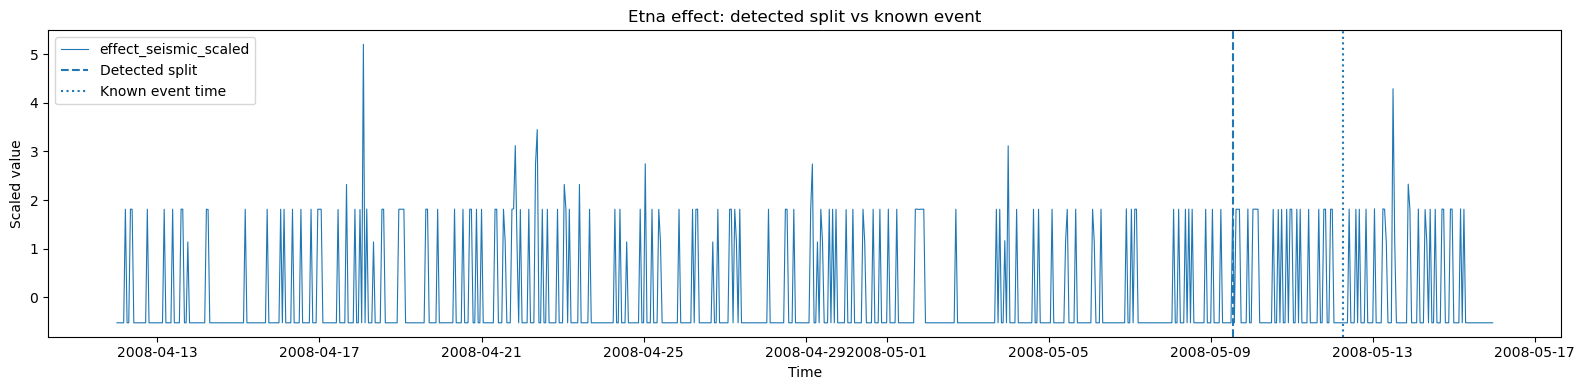

In [ ]:
plot_effect_with_split(
    X,
    EFFECT,
    results["hmml_backend_beta"],
    event_time=EVENT_TIME,
    title="Etna effect: detected split vs known event",
)


## 5. Automatic lag and sensitivity grid

In [ ]:
selected_lag = select_lag_by_var(
    X,
    EFFECT,
    max_lags=workflow.max_lags,
    criterion="aic",
    fallback_lag=1,
)
print("VAR/AIC selected lag:", selected_lag)

sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=("gaussian",),
    cond_ind_test="parcorr",
)

display(sensitivity)
display(sensitivity[sensitivity["accepted_triggers"].apply(lambda x: isinstance(x, list) and len(x) > 0)])

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


VAR/AIC selected lag: 2


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_timestamp,I1_length,I2_length,B_1,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio,error
0,effect_seismic_scaled,hmml,1,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[background_seismic_scaled],False,[background_seismic_scaled],[],[],[],0,0,None,None,None
1,effect_seismic_scaled,hmml,2,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[background_seismic_scaled],False,[background_seismic_scaled],[],[],[],0,0,None,None,None
2,effect_seismic_scaled,hmml,3,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[background_seismic_scaled],False,[background_seismic_scaled],[],[],[],0,0,None,None,None
3,effect_seismic_scaled,hmml,4,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[AirTemp_3_scaled],False,[AirTemp_3_scaled],[],[],[],0,0,None,None,None
4,effect_seismic_scaled,hmml,5,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[CO2_SO2_scaled],[AirTemp_3_scaled],False,[AirTemp_3_scaled],[],[],[],0,0,None,None,None
5,effect_seismic_scaled,hmml,6,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,155,[CO2_SO2_scaled],[CO2_SO2_scaled],False,[CO2_SO2_scaled],[],[],[],0,0,None,None,None
6,effect_seismic_scaled,pcmci,1,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,155,"[teleseismic_scaled, background_seismic_scaled, effect_seismic_scaled]",[],False,[],[],[],[],0,0,None,None,None
7,effect_seismic_scaled,pcmci,2,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None,None
8,effect_seismic_scaled,pcmci,3,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None,None
9,effect_seismic_scaled,pcmci,4,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,155,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None,None


,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_timestamp,I1_length,I2_length,B_1,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio,error
